In [1]:
# Install required libraries
# !pip install pyts
# !pip install torch
# !pip install scipy
# !pip install scikit-learn


In [2]:
# Import required libraries
import numpy as np
import matplotlib.pyplot as plt
from synthetic_gen import get_dataloader

In [3]:
# Ignore pyts warnings about quantiles
import warnings
warnings.filterwarnings('ignore', category=UserWarning, module='pyts')

In [8]:

image_size = 64
# Create a dataloader with a small batch size to visualize examples
dataloader = get_dataloader(
    n_samples=10,
    batch_size=5,
    n_timesteps=600,
    image_size=image_size,
    transform_method='all'
)


# Get a batch of data
batch = next(iter(dataloader))
signals = batch['signal']
images = batch['image']

In [5]:
batch['image'].shape

torch.Size([5, 4, 64, 64])

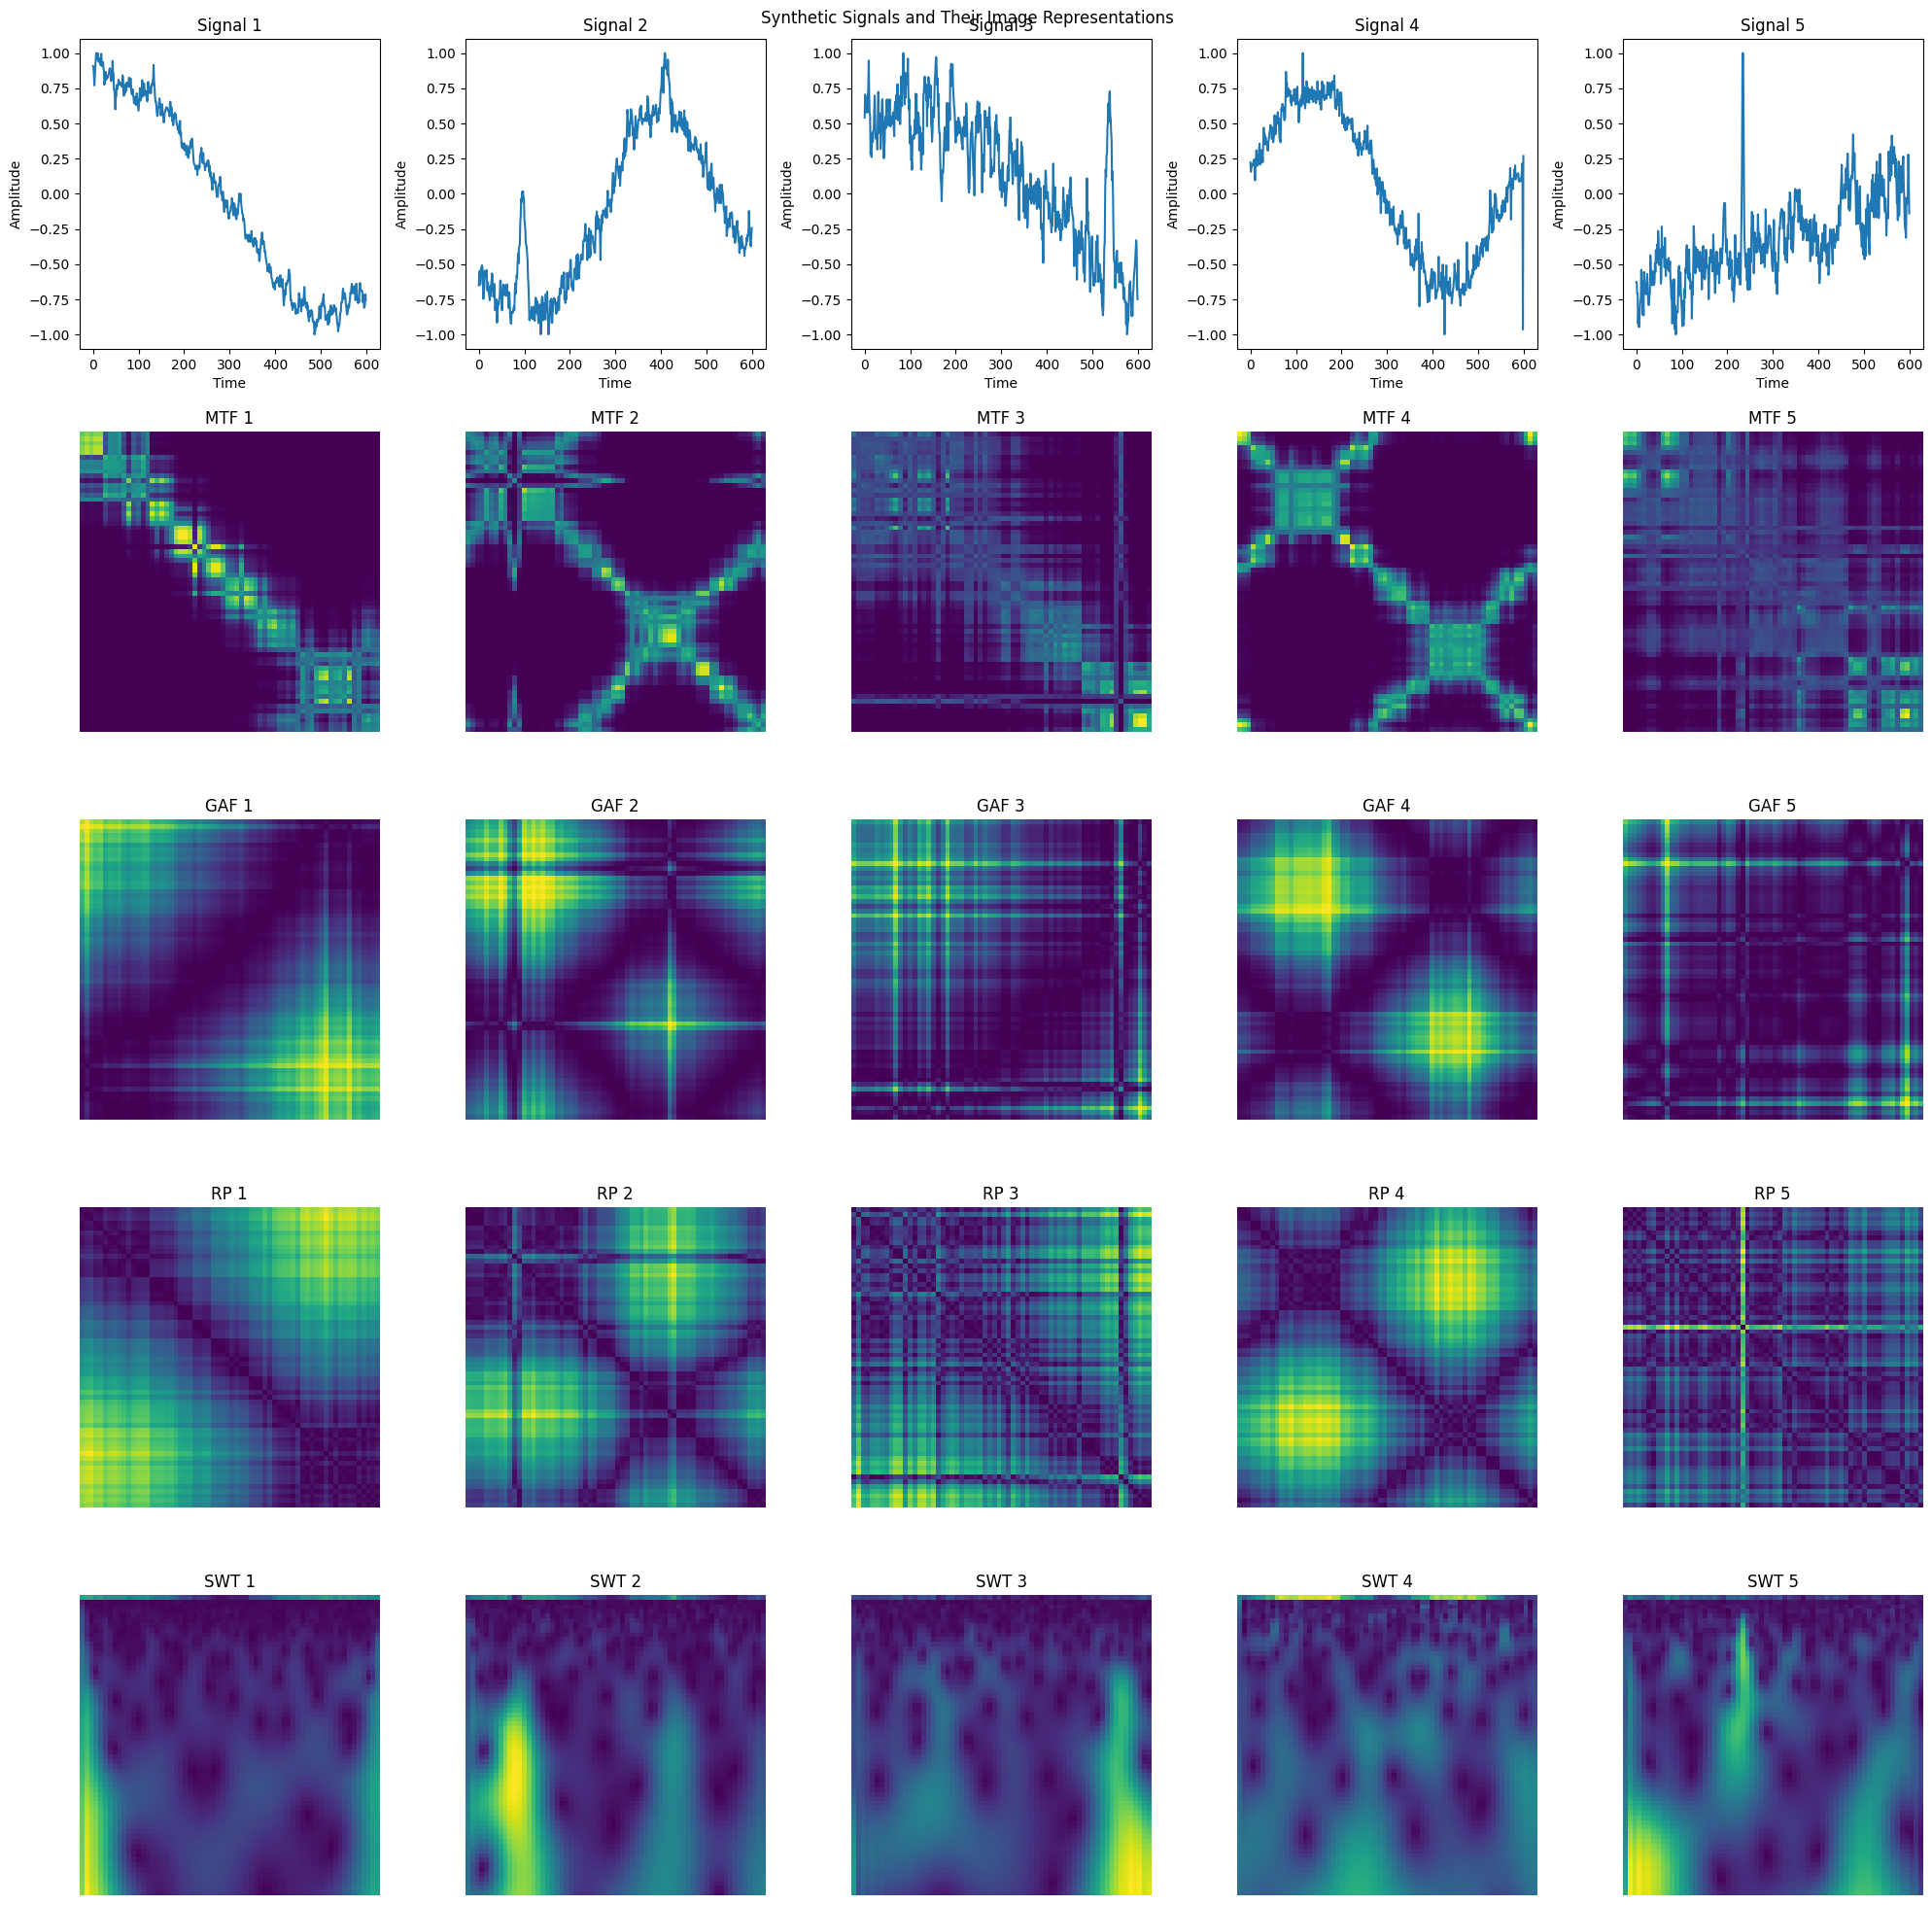

In [9]:
# Plot signals and their image representations
fig, axes = plt.subplots(5, 5, figsize=(20, 20))
fig.suptitle('Synthetic Signals and Their Image Representations')

for i in range(5):
    # Plot signal
    axes[0,i].plot(signals[i].numpy())
    axes[0,i].set_title(f'Signal {i+1}')
    axes[0,i].set_xlabel('Time')
    axes[0,i].set_ylabel('Amplitude')
    
    # Get all transformation images
    img = images[i].numpy()
    
    # Plot GASF
    im = axes[1,i].imshow(img[0], cmap='viridis')
    axes[1,i].set_title(f'MTF {i+1}')
    axes[1,i].axis('off')
    
    # Plot GADF
    im = axes[2,i].imshow(img[1], cmap='viridis')
    axes[2,i].set_title(f'GAF {i+1}')
    axes[2,i].axis('off')
    
    # Plot MTF
    im = axes[3,i].imshow(img[2], cmap='viridis')
    axes[3,i].set_title(f'RP {i+1}')
    axes[3,i].axis('off')
    
    # Plot Recurrence Plot
    im = axes[4,i].imshow(img[3], cmap='viridis')
    axes[4,i].set_title(f'SWT {i+1}')
    axes[4,i].axis('off')
    
    
plt.tight_layout()
plt.show()

In [7]:
import torch
import torch.nn as nn
import torch.nn.functional as F
import numpy as np
import argparse
import os
from torch.utils.data import DataLoader, TensorDataset
from datetime import datetime
import logging
from tqdm import tqdm
from synthetic_gen import get_dataloader

class VAE(nn.Module):
    def __init__(self, latent_dim=128, input_channels=4, image_size=64, signal_length=600):
        super(VAE, self).__init__()
        
        self.image_size = image_size
        self.signal_length = signal_length
        self.latent_dim = latent_dim
        
        # Encoder
        self.encoder = nn.Sequential(
            nn.Conv2d(input_channels, 64, kernel_size=3, stride=2, padding=1),
            nn.BatchNorm2d(64),
            nn.ReLU(),
            
            nn.Conv2d(64, 128, kernel_size=3, stride=2, padding=1),
            nn.BatchNorm2d(128),
            nn.ReLU(),
            
            nn.Conv2d(128, 256, kernel_size=3, stride=2, padding=1),
            nn.BatchNorm2d(256),
            nn.ReLU(),
            
            nn.Conv2d(256, 512, kernel_size=3, stride=2, padding=1),
            nn.BatchNorm2d(512),
            nn.ReLU(),
            
            nn.Flatten()
        )
        
        # Calculate the size of flattened features from encoder
        self.flattened_size = 512 * (image_size // 16) * (image_size // 16)
        
        # Latent space projections
        self.fc_mu = nn.Linear(self.flattened_size, latent_dim)
        self.fc_var = nn.Linear(self.flattened_size, latent_dim)
        
        # Signal decoder (MLP from latent to signal)
        self.signal_decoder = nn.Sequential(
            nn.Linear(latent_dim, 512),
            nn.ReLU(),
            nn.Linear(512, 256),
            nn.ReLU(),
            nn.Linear(256, signal_length)
        )
        
    def encode(self, x):
        x = self.encoder(x)
        mu = self.fc_mu(x)
        log_var = self.fc_var(x)
        return mu, log_var
    
    def reparameterize(self, mu, log_var):
        std = torch.exp(0.5 * log_var)
        eps = torch.randn_like(std)
        return mu + eps * std
    
    def decode(self, z):
        # Only decode into signal
        signal = self.signal_decoder(z)
        return signal
    
    def forward(self, x):
        mu, log_var = self.encode(x)
        z = self.reparameterize(mu, log_var)
        recon_signal = self.decode(z)
        return recon_signal, mu, log_var, z
    
    def loss_function(self, recon_signal, signal, mu, log_var, beta=1.0):
        """
        Computes the VAE loss function for signal reconstruction only.
        
        Args:
            recon_signal: reconstructed signal
            signal: original signal
            mu: mean of latent distribution
            log_var: log variance of latent distribution
            beta: weight for KL divergence term
            
        Returns:
            (loss, signal_loss, KLD)
        """
        # Signal reconstruction loss (MSE)
        signal_loss = F.mse_loss(recon_signal, signal, reduction='sum')
        
        # KL divergence loss
        KLD = -0.5 * torch.sum(1 + log_var - mu.pow(2) - log_var.exp())
        
        # Total loss
        loss = signal_loss + beta * KLD
        return loss, signal_loss, KLD
    
    def generate(self, num_samples=1, device='cuda'):
        """
        Generate signals from the latent space.
        
        Args:
            num_samples: number of samples to generate
            device: device to generate samples on
            
        Returns:
            generated signals
        """
        with torch.no_grad():
            z = torch.randn(num_samples, self.latent_dim).to(device)
            signals = self.decode(z)
        return signals

def setup_logging(log_dir):
    """Setup logging configuration"""
    if not os.path.exists(log_dir):
        os.makedirs(log_dir)
    
    timestamp = datetime.now().strftime('%Y%m%d_%H%M%S')
    log_file = os.path.join(log_dir, f'training_{timestamp}.log')
    
    logging.basicConfig(
        level=logging.INFO,
        format='%(asctime)s - %(levelname)s - %(message)s',
        handlers=[
            logging.FileHandler(log_file),
            logging.StreamHandler()
        ]
    )
    return log_file

def train_model(model, train_loader, val_loader, optimizer, num_epochs, device, log_dir, beta=1.0):
    """Train the VAE model for signal reconstruction"""
    model = model.to(device)
    best_val_loss = float('inf')
    
    # Create loss log file
    loss_log_file = os.path.join(log_dir, 'losses.txt')
    
    for epoch in range(num_epochs):
        # Training phase
        model.train()
        train_loss = 0
        train_signal_loss = 0
        train_kld_loss = 0
        
        with tqdm(train_loader, desc=f'Epoch {epoch+1}/{num_epochs}') as pbar:
            for batch_idx, batch in enumerate(pbar):
                data = batch['image'].to(device)
                signals = batch['signal'].to(device)
                
                optimizer.zero_grad()
                recon_signal, mu, log_var, z = model(data)
                
                loss, signal_loss, kld_loss = model.loss_function(
                    recon_signal, signals, mu, log_var, beta
                )
                
                loss.backward()
                optimizer.step()
                
                train_loss += loss.item()
                train_signal_loss += signal_loss.item()
                train_kld_loss += kld_loss.item()
                
                pbar.set_postfix({
                    'loss': loss.item() / len(data),
                    'signal_loss': signal_loss.item() / len(data),
                    'kld_loss': kld_loss.item() / len(data)
                })
        
        # Validation phase
        model.eval()
        val_loss = 0
        val_signal_loss = 0
        val_kld_loss = 0
        
        with torch.no_grad():
            for batch in val_loader:
                data = batch['image'].to(device)
                signals = batch['signal'].to(device)
                
                recon_signal, mu, log_var, z = model(data)
                loss, signal_loss, kld_loss = model.loss_function(
                    recon_signal, signals, mu, log_var, beta
                )
                
                val_loss += loss.item()
                val_signal_loss += signal_loss.item()
                val_kld_loss += kld_loss.item()
        
        # Calculate average losses
        train_loss /= len(train_loader.dataset)
        train_signal_loss /= len(train_loader.dataset)
        train_kld_loss /= len(train_loader.dataset)
        val_loss /= len(val_loader.dataset)
        val_signal_loss /= len(val_loader.dataset)
        val_kld_loss /= len(val_loader.dataset)
        
        # Log losses
        with open(loss_log_file, 'a') as f:
            f.write(f'Epoch {epoch+1}:\n')
            f.write(f'Train Loss: {train_loss:.6f}, Train Signal Loss: {train_signal_loss:.6f}, Train KLD: {train_kld_loss:.6f}\n')
            f.write(f'Val Loss: {val_loss:.6f}, Val Signal Loss: {val_signal_loss:.6f}, Val KLD: {val_kld_loss:.6f}\n\n')
        
        logging.info(f'Epoch {epoch+1}:')
        logging.info(f'Train Loss: {train_loss:.6f}, Train Signal Loss: {train_signal_loss:.6f}, Train KLD Loss: {train_kld_loss:.6f}')
        logging.info(f'Val Loss: {val_loss:.6f}, Val Signal Loss: {val_signal_loss:.6f}, Val KLD Loss: {val_kld_loss:.6f}')
        
        # Save best model
        if val_loss < best_val_loss:
            best_val_loss = val_loss
            torch.save(model.state_dict(), os.path.join(log_dir, 'best_model.pth'))
            logging.info('Saved best model')
        
        # Save checkpoint
        if (epoch + 1) % 10 == 0:
            torch.save({
                'epoch': epoch,
                'model_state_dict': model.state_dict(),
                'optimizer_state_dict': optimizer.state_dict(),
                'train_loss': train_loss,
                'val_loss': val_loss,
            }, os.path.join(log_dir, f'checkpoint_epoch_{epoch+1}.pth'))
            logging.info(f'Saved checkpoint for epoch {epoch+1}')


In [11]:
import torch 
import os 

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
output_dir = './outputs/'
n_samples = 100000
batch_size = 16
n_features = 4
n_timesteps = 600
image_size = 64
transform_method = 'all'
seed = 42
latent_dim = 128
learning_rate = 1e-3
num_epochs = 20
beta = 0.1

# os.makedirs(output_dir, exist_ok=True)


# Create output directory
timestamp = datetime.now().strftime('%Y%m%d_%H%M%S')
output_dir = os.path.join(output_dir, f'run_{timestamp}')
os.makedirs(output_dir, exist_ok=True)

# Setup logging
log_file = setup_logging(output_dir)
# logging.info(f'Starting training with arguments: {args}')

# Set device
device = torch.device(device if torch.cuda.is_available() else 'cpu')
logging.info(f'Using device: {device}')

# Generate synthetic data
logging.info('Generating synthetic data...')

# Split data
train_size = int(0.8 * n_samples)
val_size = n_samples - train_size

# Create dataloaders
train_loader = get_dataloader(
    n_samples=train_size,
    batch_size=batch_size,
    n_features=n_features,
    n_timesteps=n_timesteps,
    image_size=image_size,
    transform_method=transform_method,
    seed=seed,
    num_workers=2,
    shuffle=True
)

val_loader = get_dataloader(
    n_samples=val_size,
    batch_size=batch_size,
    n_features=n_features,
    n_timesteps=n_timesteps,
    image_size=image_size,
    transform_method=transform_method,
    seed=seed + 1,
    num_workers=2,
    shuffle=False
)

logging.info(f'Generated {train_size} training samples and {val_size} validation samples')

# Initialize model
model = VAE(
    latent_dim=latent_dim,
    input_channels=4,
    image_size=image_size,
    signal_length=n_timesteps
)
optimizer = torch.optim.Adam(model.parameters(), lr=learning_rate)

# Train model
# train_model(
#     model=model,
#     train_loader=train_loader, 
#     val_loader=val_loader, 
#     optimizer=optimizer, 
#     num_epochs=num_epochs, 
#     device=device, 
#     log_dir=output_dir, 
#     beta=beta 
# )

logging.info('Training completed')



2025-04-19 14:32:17,453 - INFO - Using device: cpu
2025-04-19 14:32:17,454 - INFO - Generating synthetic data...
2025-04-19 14:32:17,456 - INFO - Generated 80000 training samples and 20000 validation samples
2025-04-19 14:32:17,935 - INFO - Training completed


In [12]:
os.listdir('outputs')

['run_20250419_143217', 'run_20250419_125721', 'run_20250419_124846']

In [13]:
output_dir = "./outputs/run_20250419_125721"

checkpoint_path = f"{output_dir}/best_model.pth"
logging.info(f"Loading model from {checkpoint_path}")
model.load_state_dict(torch.load(checkpoint_path, map_location=device))
model.to(device)
model.eval()
logging.info("Model loaded successfully")


2025-04-19 14:33:14,411 - INFO - Loading model from ./outputs/run_20250419_125721/best_model.pth
2025-04-19 14:33:14,423 - INFO - Model loaded successfully


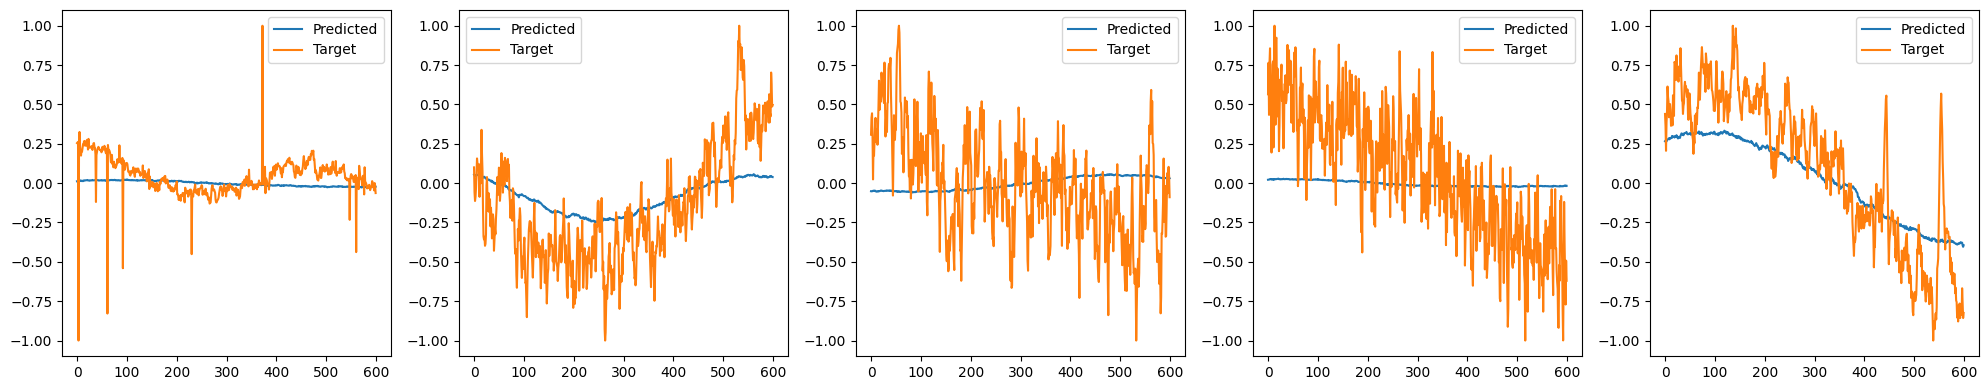

In [28]:
batch = next(iter(dataloader))

signals, _, _, _ = model(batch['image'])

# Plot the 5 output signals
fig, axs = plt.subplots(1, len(signals), figsize=(20, 4))
for i in range(len(signals)):
    axs[i].plot(signals[i].detach().numpy(), label='Predicted')
    axs[i].plot(batch['signal'][i].detach().numpy(), label='Target')
    axs[i].legend()
plt.tight_layout()
plt.show()